# Milestone 1 – Voxel World: Representation, Encoding, and Fitness


## Imports

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

from src.representation import (
    random_genome, largest_connected_component,
    EMPTY, PASSIVE, ACTIVE_P, ACTIVE_N, N_MATERIALS,
    genome_to_vxa, count_voxels
)
from src.fitness import evaluate_genome, get_backend
from src.Visualize import render_genome, render_side_by_side
from src.diagnostics import plot_component_distribution, plot_fitness_landscape



## 5.1.1 – Implement & Test the Voxel Genome

In [3]:
# Generate a single random genome 
np.random.seed(42)
g = random_genome(grid_size=(8, 8, 8), density=0.4)

print('Shape:', g.shape)
print('dtype:', g.dtype)
print('Unique values:', np.unique(g)) #4 materials
print('Voxel counts:', count_voxels(g)) #doesnt count empty voxels


Shape: (8, 8, 8)
dtype: int32
Unique values: [0 1 2 3]
Voxel counts: {'total': 215, 'passive': 75, 'active_p': 63, 'active_n': 77}


In [4]:
# largest_connected_component
g_repaired = largest_connected_component(g)
filled_before = (g != EMPTY)
filled_after  = (g_repaired != EMPTY)

_, n_before = label(filled_before)
_, n_after  = label(filled_after.astype(int))

print(f'Components before repair: {n_before}')
print(f'Components after  repair: {n_after}')


Components before repair: 27
Components after  repair: 1


## 5.1.2 – Fitness Function

In [5]:
# Evaluate a single genome
fitness = evaluate_genome(g)
print(f'Fitness tuple: {fitness}')
print(f'Fitness value: {fitness[0]:.4f}')


Fitness tuple: (0.5049133386676212,)
Fitness value: 0.5049


## Reflection Question 5 – Search Space Size

In [6]:
# Q5: Size of search space for 8x8x8 grid with 4 material types
N = 8
grid_cells = N ** 3
search_space = N_MATERIALS ** grid_cells

import math
log10_search = grid_cells * math.log10(N_MATERIALS)
log10_atoms  = 80   # observable universe ~10^80 atoms

print(f'Grid cells: {grid_cells}')
print(f'Search space: 4^{grid_cells} = 10^{log10_search:.0f}')
print(f'Observable universe atoms: ~10^{log10_atoms}')
print(f'Ratio (search / atoms): 10^{log10_search - log10_atoms:.0f}')
print()
print('Brute force search is impossible.As, all possible robot designs evolution could explore.trying every robot one-by-one is impossible')
print('So intelligent search is necessary like evolution')


Grid cells: 512
Search space: 4^512 = 10^308
Observable universe atoms: ~10^80
Ratio (search / atoms): 10^228

Brute force search is impossible.As, all possible robot designs evolution could explore.trying every robot one-by-one is impossible
So intelligent search is necessary like evolution


## Reflection Question 6 – Connected Components

In [7]:
import os
os.makedirs('../results', exist_ok=True)

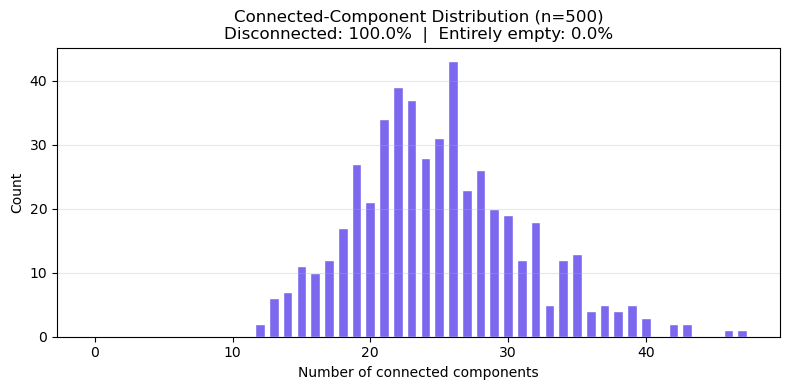

ALL 500 random genomes had:more than 1 component therefore disconnected.

y - axis contains number of connected components and x-axis contains how many genome at that values
A large fraction of random genomes are structurally fragmented.
Naive random search would waste most evaluations on unviable bodies.As itmay result in Invalid body, floating pieces and meaningless morphology
Connectivity repair is therefore essential.


In [23]:
#Q If we randomly generate robot bodies (genomes), how many are actually valid/connected?
fig, frac_disc = plot_component_distribution(n_samples=500, save_path='../results/q6_components.png')
plt.show()

print('ALL 500 random genomes had:more than 1 component therefore disconnected.')
print()
print('y - axis contains number of connected components and x-axis contains how many genome at that values')
print('A large fraction of random genomes are structurally fragmented.')
print('Naive random search would waste most evaluations on unviable bodies.As itmay result in Invalid body, floating pieces and meaningless morphology')
print('Connectivity repair is therefore essential.')

## Reflection Question 7 – Visualise 5 Random Genomes

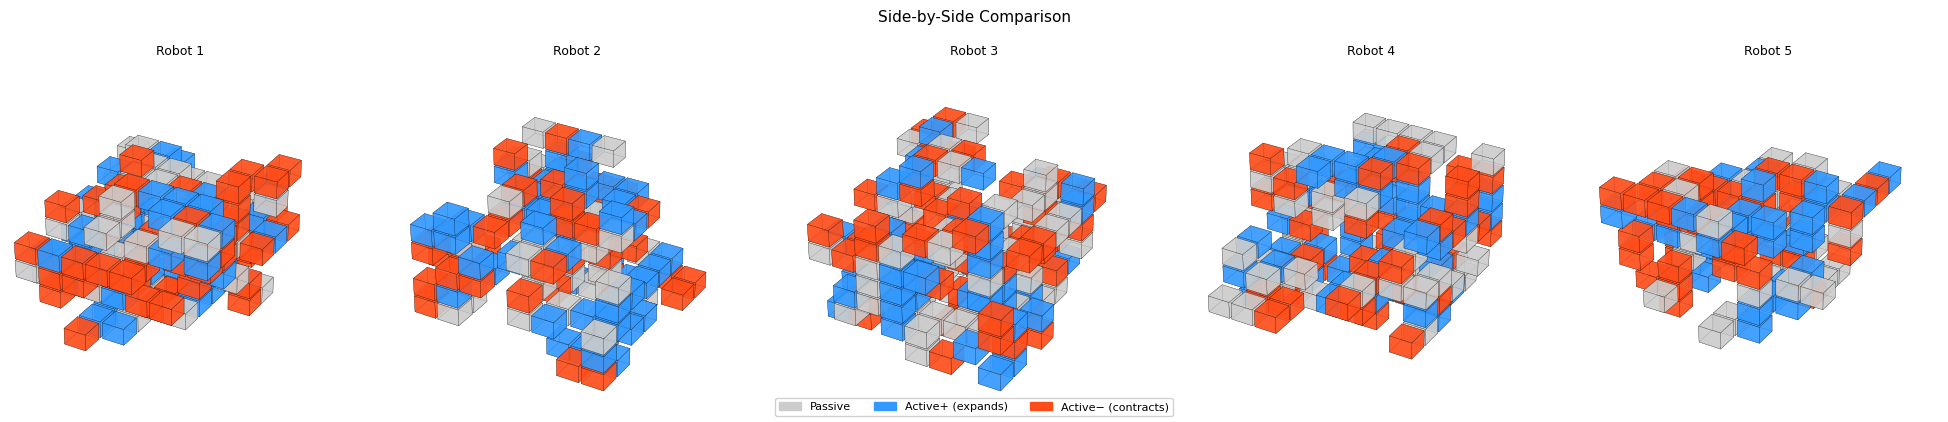

Robot 1
Fitness: 0.478
Total voxels: 162
Passive voxels: 44
ACTIVE_P voxels: 55
ACTIVE_N voxels: 63

Robot 2
Fitness: 0.462
Total voxels: 127
Passive voxels: 37
ACTIVE_P voxels: 49
ACTIVE_N voxels: 41

Robot 3
Fitness: 0.521
Total voxels: 167
Passive voxels: 62
ACTIVE_P voxels: 52
ACTIVE_N voxels: 53

Robot 4
Fitness: 0.503
Total voxels: 147
Passive voxels: 53
ACTIVE_P voxels: 49
ACTIVE_N voxels: 45

Robot 5
Fitness: 0.452
Total voxels: 109
Passive voxels: 35
ACTIVE_P voxels: 36
ACTIVE_N voxels: 38

Mixed active materials may improve locomotion
Robot 3 achieved the highest fitness because it had a well-balanced distribution of ACTIVE_P and ACTIVE_N voxels along with a stable body size.
 Robot 5 is having the least fitness even though it has a balanced distribution.Robot 5 can score well on phase balance but poorly on body size/density/asymmetry
Highest fitness robot: Robot 3
Lowest fitness robot: Robot 5

Interpretation:
- Robot 3 achieved highest fitness.
- Robot 5 achieved lowest fit

In [18]:
# Generate 5 random connected genomes
np.random.seed(7)

five_genomes = [
    largest_connected_component(random_genome())
    for _ in range(5)
]

five_titles = [f'Robot {i+1}' for i in range(5)]

# Visualize robots
fig = render_side_by_side(
    five_genomes,
    five_titles,
    save_path='../results/q7_five_robots.png'
)

plt.show()


# Evaluate robots
fitness_scores = []

for i, genome in enumerate(five_genomes):

    # Evaluate fitness
    fitness = evaluate_genome(genome, sim_time=5)[0]
    fitness_scores.append(fitness)

    # Count voxels
    counts = count_voxels(genome)

    print(f'Robot {i+1}')
    print(f'Fitness: {fitness:.3f}')
    print(f"Total voxels: {counts['total']}")
    print(f"Passive voxels: {counts['passive']}")
    print(f"ACTIVE_P voxels: {counts['active_p']}")
    print(f"ACTIVE_N voxels: {counts['active_n']}")
    print()


# Overall comparison
print('Mixed active materials may improve locomotion')
print('Robot 3 achieved the highest fitness because it had a well-balanced distribution of ACTIVE_P and ACTIVE_N voxels along with a stable body size.')
print(' Robot 5 is having the least fitness even though it has a balanced distribution.Robot 5 can score well on phase balance but poorly on body size/density/asymmetry')


best_robot = np.argmax(fitness_scores) + 1
worst_robot = np.argmin(fitness_scores) + 1

print(f'Highest fitness robot: Robot {best_robot}')
print(f'Lowest fitness robot: Robot {worst_robot}')

print('\nInterpretation:')

best_robot = np.argmax(fitness_scores) + 1
worst_robot = np.argmin(fitness_scores) + 1

print(f'- Robot {best_robot} achieved highest fitness.')
print(f'- Robot {worst_robot} achieved lowest fitness.')

print('- Robots with asymmetric active voxel layouts may')
print('  produce stronger directional locomotion.')
print(' As if body symmetric then left muscle pushes right muscle pushes equally, so the body wiggle in place')

print('- Compact bodies generally appear more stable and')
print('  may achieve better fitness.')

print('- Tall thin bodies may lose stability during')
print('  simulation, reducing fitness.')

## Reflection Question 8 – Complexity Budget Threshold

In [21]:
# increase in n affects fitness evaluation time?
import time

print('Timing fitness evaluation for different grid sizes...')
print('(Using heuristic backend – times will differ with real simulator)\n')

threshold_N = None
for N in [4, 6, 8, 10, 12, 14, 16]:
    g_test = random_genome(grid_size=(N, N, N))
    t0 = time.time()
    for _ in range(5):   # average over 5 runs
        evaluate_genome(g_test)
    elapsed = (time.time() - t0) / 5
    print(f'N={N:2d} ({N**3:4d} cells): {elapsed*1000:.2f} ms per evaluation')
    if elapsed >= 1.0 and threshold_N is None:
        threshold_N = N

if threshold_N:
    print(f'\nComplexity budget threshold: N = {threshold_N}')
else:
    print('\nNote: heuristic backend is very fast. Threshold relevant for real sim.')

Timing fitness evaluation for different grid sizes...
(Using heuristic backend – times will differ with real simulator)

N= 4 (  64 cells): 0.55 ms per evaluation
N= 6 ( 216 cells): 0.42 ms per evaluation
N= 8 ( 512 cells): 0.18 ms per evaluation
N=10 (1000 cells): 0.27 ms per evaluation
N=12 (1728 cells): 0.50 ms per evaluation
N=14 (2744 cells): 0.58 ms per evaluation
N=16 (4096 cells): 1.44 ms per evaluation

Note: heuristic backend is very fast. Threshold relevant for real sim.


## VXA Serialisation Test

In [20]:
import os
os.makedirs('../results', exist_ok=True)

test_genome = largest_connected_component(random_genome())
genome_to_vxa(test_genome, '../results/test_robot.vxa', sim_time=1.0)

# Verify the file was created and is valid XML
import xml.etree.ElementTree as ET
tree = ET.parse('../results/test_robot.vxa')
root = tree.getroot()
print('VXA file tag:', root.tag)
print('VXA version:', root.get('Version'))
print('File created: ../results/test_robot.vxa')
print('VXA serialisation OK')

VXA file tag: VXA
VXA version: 1.1
File created: ../results/test_robot.vxa
VXA serialisation OK
